## **computer vision - lab 3 tasks**

### **23K-0074**

#### **task** 1

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("cv_image.jpg")

if image is None:
    print("error: image not found")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    print(f"image loaded successfully - width: {width}, height: {height}")

image loaded successfully - width: 738, height: 414


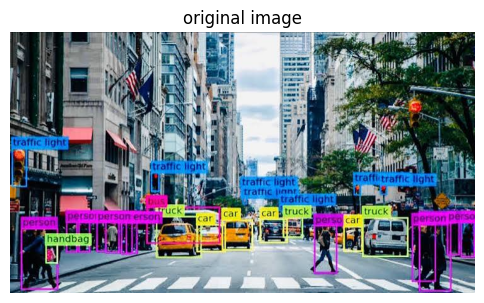

In [16]:
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("original image")
plt.axis("off")
plt.show()

2x2 scaling matrix:
[[3. 0.]
 [0. 3.]]

full 2x3 affine matrix (scale + center offset):
[[   3.    0. -738.]
 [   0.    3. -414.]]


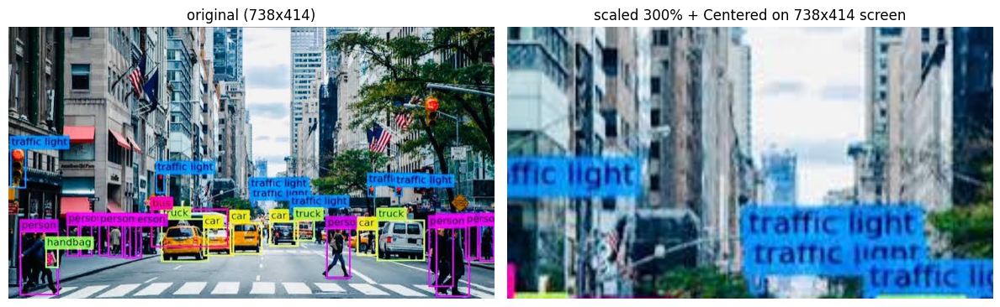

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#original dims
height, width = image.shape[:2]

#scale factors: enlarge by 300% -> new size = 3x original
sx = 3.0
sy = 3.0

#building the 2x2 scaling matrix
scale_matrix_2x2 = np.array([
    [sx, 0],
    [0,  sy]
])

print("2x2 scaling matrix:")
print(scale_matrix_2x2)

#canvas stays at ORIGINAL size (this is the "screen" the fingerprint must be centered on)
new_width = width
new_height = height

#centering offset
#scaling around origin (0,0) grows the image to the bottom-right, off-screen.
#to center it on the original-size canvas, shift left/up by half the
#difference between the scaled size and the canvas size.
tx = (width - width * sx) / 2
ty = (height - height * sy) / 2

#full 2x3 affine matrix: scaling + translation
M = np.float32([
    [sx, 0,  tx],
    [0,  sy, ty]
])

print("\nfull 2x3 affine matrix (scale + center offset):")
print(M)

#apply the transformation onto the original-size canvas
scaled = cv2.warpAffine(image, M, (new_width, new_height))

#BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
scaled_rgb = cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"original ({width}x{height})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(scaled_rgb)
plt.title(f"scaled 300% + Centered on {new_width}x{new_height} screen")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 2**

2x2 rotation matrix:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

original size: 738x414
new canvas size after rotation: 814x814

full 2x3 affine matrix (rotation about center, on expanded canvas):
[[  0.70710677  -0.70710677 292.4487    ]
 [  0.70710677   0.70710677  -0.29350597]]


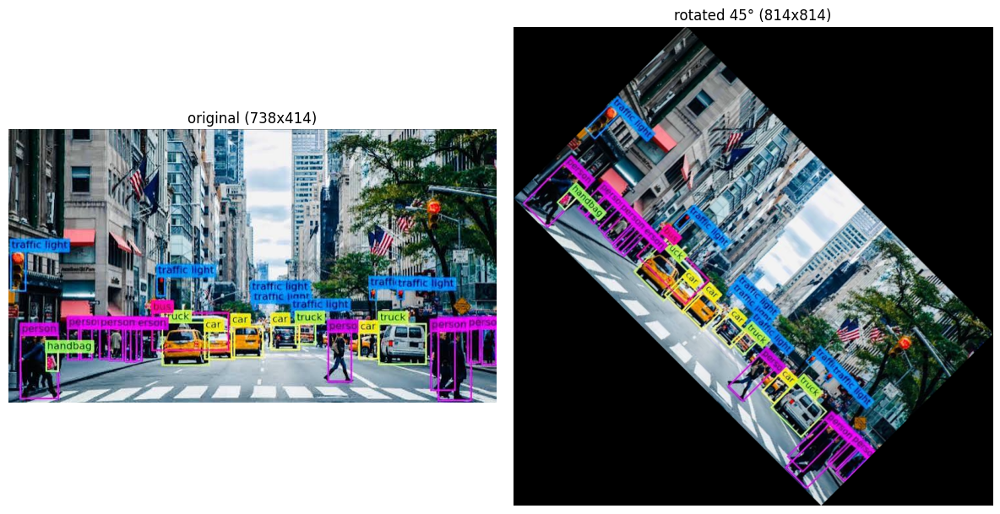

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#original dims
height, width = image.shape[:2]

#rotation angle: 45 degrees
angle_deg = 45
angle_rad = np.deg2rad(angle_deg)

#manually build the 2x2 rotation matrix using sine and cosine
cos_a = np.cos(angle_rad)
sin_a = np.sin(angle_rad)

rotation_matrix_2x2 = np.array([
    [cos_a, -sin_a],
    [sin_a,  cos_a]
])

print("2x2 rotation matrix:")
print(rotation_matrix_2x2)

#manually calculate new canvas dimensions so corners aren't chopped off
#new bounding box for a rotated w x h rectangle:
new_width = int(abs(width * cos_a) + abs(height * sin_a))
new_height = int(abs(width * sin_a) + abs(height * cos_a))

print(f"\noriginal size: {width}x{height}")
print(f"new canvas size after rotation: {new_width}x{new_height}")

#translation to keep the rotated image centered on the new, larger canvas
#rotation happens around the origin (0,0), so after rotating we shift
#by half the new canvas size, then pull back by half the original center
tx = new_width / 2 - width / 2
ty = new_height / 2 - height / 2

#full 2x3 affine matrix: rotation (around origin) + shift to re-center
#to rotate around the IMAGE CENTER (not the corner), we combine three steps:
#move center to origin -> rotate -> move back to new center
cx, cy = width / 2, height / 2
new_cx, new_cy = new_width / 2, new_height / 2

M = np.float32([
    [cos_a, -sin_a, new_cx - (cos_a * cx - sin_a * cy)],
    [sin_a,  cos_a, new_cy - (sin_a * cx + cos_a * cy)]
])

print("\nfull 2x3 affine matrix (rotation about center, on expanded canvas):")
print(M)

#apply rotation
rotated = cv2.warpAffine(image, M, (new_width, new_height))

#BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"original ({width}x{height})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_rgb)
plt.title(f"rotated {angle_deg}° ({new_width}x{new_height})")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 3**

2x2 shear matrix:
[[ 1.  -0.5]
 [ 0.   1. ]]

full 2x3 affine matrix (shear + offset):
[[ 1.  -0.5  0. ]
 [ 0.   1.   0. ]]


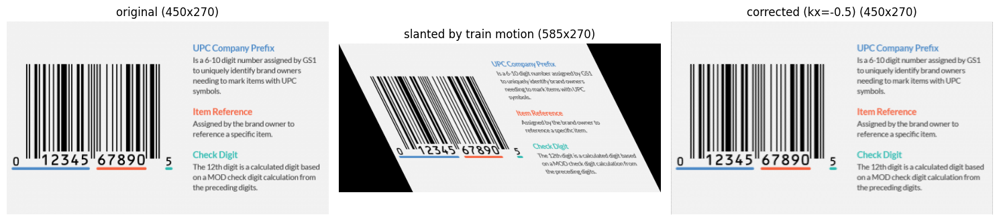

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

barcode = cv2.imread("barcode.png")

if barcode is None:
    print("error: barcode.png not found")
else:
    height, width = barcode.shape[:2]

    #step 1: simulate the train-motion slant (positive shear tilts it right)
    kx_slant = 0.5
    slant_matrix = np.float32([
        [1, kx_slant, 0],
        [0, 1, 0]
    ])
    slant_width = int(width + abs(kx_slant) * height)
    slanted = cv2.warpAffine(barcode, slant_matrix, (slant_width, height))

    #step 2: correct the slant with the opposite shear
    kx = -kx_slant

    shear_matrix_2x2 = np.array([
        [1, kx],
        [0, 1]
    ])
    print("2x2 shear matrix:")
    print(shear_matrix_2x2)

    new_width = width
    new_height = height

    tx = 0
    ty = 0

    M = np.float32([
        [1, kx, tx],
        [0, 1, ty]
    ])

    print("\nfull 2x3 affine matrix (shear + offset):")
    print(M)

    corrected = cv2.warpAffine(slanted, M, (new_width, new_height))

    barcode_rgb = cv2.cvtColor(barcode, cv2.COLOR_BGR2RGB)
    slanted_rgb = cv2.cvtColor(slanted, cv2.COLOR_BGR2RGB)
    corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(barcode_rgb)
    plt.title(f"original ({width}x{height})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(slanted_rgb)
    plt.title(f"slanted by train motion ({slant_width}x{height})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(corrected_rgb)
    plt.title(f"corrected (kx={kx}) ({new_width}x{new_height})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# **task 4**

3x3 translation matrix (homogeneous coordinates):
[[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]

2x3 matrix passed to warpAffine:
[[  1.   0. 150.]
 [  0.   1.  80.]]


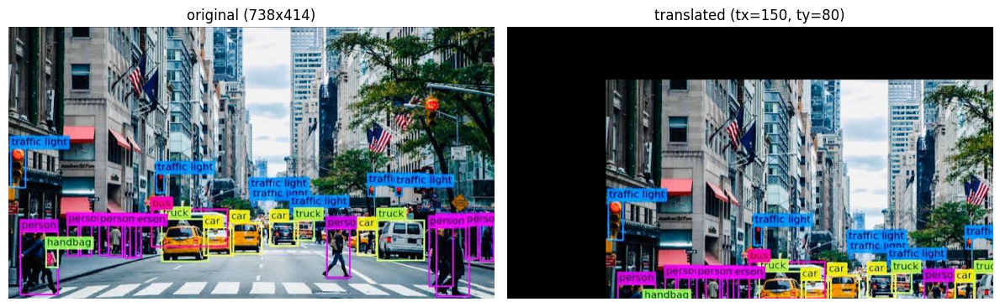

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#original dims
height, width = image.shape[:2]

#the "X marks the spot" is hidden 150px to the left and 80px up (off-screen)
#to bring it back INTO view, we shift the image content in the OPPOSITE
#direction of where it's hidden -> shift right and down
tx = 150
ty = 80

#upgrading from 2x2 to 3x3 using homogeneous coordinates
#this allows pure matrix multiplication to represent translation
translation_matrix_3x3 = np.float32([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

print("3x3 translation matrix (homogeneous coordinates):")
print(translation_matrix_3x3)

#warpAffine only needs the top 2 rows (2x3), since it assumes
#the bottom row is always [0, 0, 1]
M = translation_matrix_3x3[:2, :]

print("\n2x3 matrix passed to warpAffine:")
print(M)

#apply translation on a canvas the SAME size as the original
#(the map is misaligned within a fixed viewing frame, not being resized)
translated = cv2.warpAffine(image, M, (width, height))

#BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"original ({width}x{height})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_rgb)
plt.title(f"translated (tx={tx}, ty={ty})")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 5**

3x3 rotation matrix:
[[ 0.8660254 -0.5        0.       ]
 [ 0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]

3x3 translation matrix:
[[ 1  0 60]
 [ 0  1 40]
 [ 0  0  1]]

combined 3x3 rigid transformation matrix (T * R):
[[ 0.8660254 -0.5       60.       ]
 [ 0.5        0.8660254 40.       ]
 [ 0.         0.         1.       ]]

2x3 matrix passed to warpAffine:
[[ 0.8660254 -0.5       60.       ]
 [ 0.5        0.8660254 40.       ]]


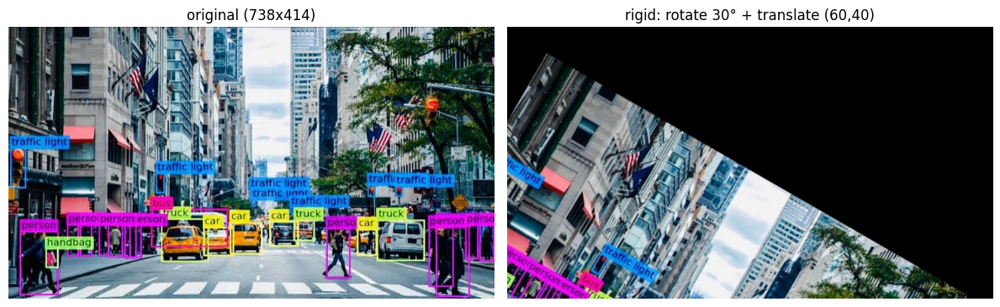

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#original dims
height, width = image.shape[:2]

#scenario: chip is rotated sideways and slightly off-center
#let's rotate by 30 degrees and shift it to align with the gripper
angle_deg = 30
angle_rad = np.deg2rad(angle_deg)

cos_a = np.cos(angle_rad)
sin_a = np.sin(angle_rad)

#translation values (moving the chip to align with the gripper position)
tx = 60
ty = 40

#build the 3x3 ROTATION matrix (homogeneous form)
rotation_3x3 = np.array([
    [cos_a, -sin_a, 0],
    [sin_a, cos_a, 0],
    [0, 0, 1]
])

#build the 3x3 TRANSLATION matrix (homogeneous form)
translation_3x3 = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

print("3x3 rotation matrix:")
print(rotation_3x3)
print("\n3x3 translation matrix:")
print(translation_3x3)

#COMBINE into a single rigid transformation matrix
#order matters: translate AFTER rotating (T * R), so the object
#rotates first around the origin, then gets moved into place
rigid_3x3 = translation_3x3 @ rotation_3x3

print("\ncombined 3x3 rigid transformation matrix (T * R):")
print(rigid_3x3)

#warpAffine needs the top 2 rows only
M = rigid_3x3[:2, :].astype(np.float32)

print("\n2x3 matrix passed to warpAffine:")
print(M)

#apply the combined transformation simultaneously
rigid = cv2.warpAffine(image, M, (width, height))

#BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
rigid_rgb = cv2.cvtColor(rigid, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"original ({width}x{height})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rigid_rgb)
plt.title(f"rigid: rotate {angle_deg}° + translate ({tx},{ty})")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 6**

scale matrix:
 [[1.5 0.  0. ]
 [0.  1.5 0. ]
 [0.  0.  1. ]]

rotation matrix:
 [[ 0.93969262 -0.34202014  0.        ]
 [ 0.34202014  0.93969262  0.        ]
 [ 0.          0.          1.        ]]

translation matrix:
 [[ 1  0 80]
 [ 0  1 50]
 [ 0  0  1]]

combined 3x3 similarity matrix (T * R * S):
[[ 1.40953893 -0.51303021 80.        ]
 [ 0.51303021  1.40953893 50.        ]
 [ 0.          0.          1.        ]]

2x3 matrix passed to warpAffine:
[[ 1.409539   -0.51303023 80.        ]
 [ 0.51303023  1.409539   50.        ]]


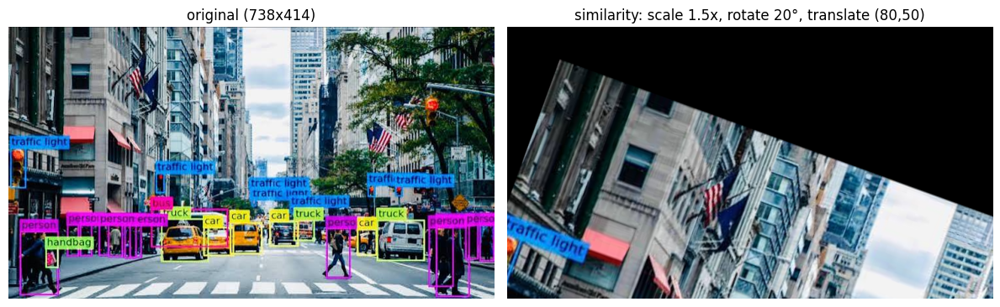

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#original dims
height, width = image.shape[:2]

#scenario: blueprint is too small, rotated randomly, and misplaced
#similarity transform = uniform scale + rotation + translation (angles preserved)

#scale factor (fixing "too small")
s = 1.5

#rotation angle (fixing "rotated randomly")
angle_deg = 20
angle_rad = np.deg2rad(angle_deg)
cos_a = np.cos(angle_rad)
sin_a = np.sin(angle_rad)

#translation (fixing "wrong corner" placement)
tx = 80
ty = 50

#build 3x3 SCALE matrix
scale_3x3 = np.array([
    [s, 0, 0],
    [0, s, 0],
    [0, 0, 1]
])

#build 3x3 ROTATION matrix
rotation_3x3 = np.array([
    [cos_a, -sin_a, 0],
    [sin_a, cos_a, 0],
    [0, 0, 1]
])

#build 3x3 TRANSLATION matrix
translation_3x3 = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

print("scale matrix:\n", scale_3x3)
print("\nrotation matrix:\n", rotation_3x3)
print("\ntranslation matrix:\n", translation_3x3)

#combine ALL THREE into one similarity transformation matrix
#order: Translate * Rotate * Scale -> scale first, then rotate, then move into place
similarity_3x3 = translation_3x3 @ rotation_3x3 @ scale_3x3

print("\ncombined 3x3 similarity matrix (T * R * S):")
print(similarity_3x3)

#warpAffine needs top 2 rows
M = similarity_3x3[:2, :].astype(np.float32)

print("\n2x3 matrix passed to warpAffine:")
print(M)

#apply
similarity = cv2.warpAffine(image, M, (width, height))

#BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
similarity_rgb = cv2.cvtColor(similarity, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"original ({width}x{height})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(similarity_rgb)
plt.title(f"similarity: scale {s}x, rotate {angle_deg}°, translate ({tx},{ty})")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 7**

landmarks in glitched image:
 [[151.4198  134.26103]
 [577.8081  236.06802]
 [217.85141 331.74918]]

landmarks in original image:
 [[100. 100.]
 [638. 120.]
 [150. 314.]]

6x6 system matrix A:
 [[151.4197998  134.2610321    1.           0.           0.
    0.        ]
 [  0.           0.           0.         151.4197998  134.2610321
    1.        ]
 [577.80810547 236.06802368   1.           0.           0.
    0.        ]
 [  0.           0.           0.         577.80810547 236.06802368
    1.        ]
 [217.85140991 331.74917603   1.           0.           0.
    0.        ]
 [  0.           0.           0.         217.85140991 331.74917603
    1.        ]]

solved 6 unknowns [a, b, tx, c, d, ty]:
 [  1.30622144  -0.18621064 -72.78695594  -0.23032209   1.16108574
 -21.0132447 ]

recovered 2x3 affine matrix:
 [[  1.30622144  -0.18621064 -72.78695594]
 [ -0.23032209   1.16108574 -21.0132447 ]]

cv2.getAffineTransform for comparison:
 [[  1.30622144  -0.18621064 -72.78695594]
 [ -0.2303

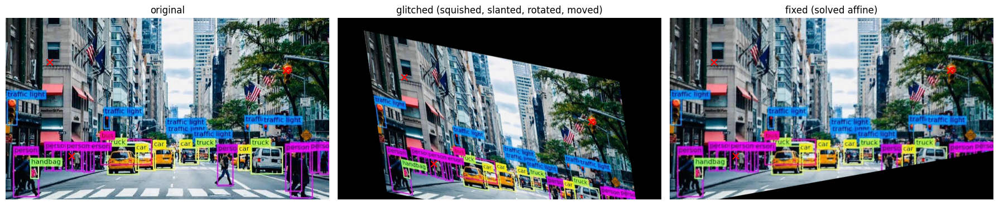

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("cv_image.jpg")
height, width = image.shape[:2]

#simulate the corrupted transmission: squish + slant + rotate + move
a = np.deg2rad(10)
glitch = np.float32([
    [0.8 * np.cos(a), -np.sin(a) + 0.3, 60],
    [0.9 * np.sin(a), 0.9 * np.cos(a), 30]
])
glitched = cv2.warpAffine(image, glitch, (width, height))

#3 landmarks: where they should be (original) and where they ended up (glitched)
orig_pts = np.float32([[100, 100], [width - 100, 120], [150, height - 100]])
glitch_pts = cv2.transform(orig_pts.reshape(-1, 1, 2), glitch).reshape(-1, 2)

print("landmarks in glitched image:\n", glitch_pts)
print("\nlandmarks in original image:\n", orig_pts)

#each point gives 2 equations:
#u = a*x + b*y + tx
#v = c*x + d*y + ty
A, b = [], []
for (x, y), (u, v) in zip(glitch_pts, orig_pts):
    A.append([x, y, 1, 0, 0, 0]); b.append(u)
    A.append([0, 0, 0, x, y, 1]); b.append(v)

A = np.array(A, dtype=np.float64)
b = np.array(b, dtype=np.float64)

print("\n6x6 system matrix A:\n", A)

params = np.linalg.solve(A, b)
M = params.reshape(2, 3)

print("\nsolved 6 unknowns [a, b, tx, c, d, ty]:\n", params)
print("\nrecovered 2x3 affine matrix:\n", M)
print("\ncv2.getAffineTransform for comparison:\n", cv2.getAffineTransform(glitch_pts, orig_pts))

fixed = cv2.warpAffine(glitched, M.astype(np.float32), (width, height))

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.scatter(orig_pts[:, 0], orig_pts[:, 1], c='red', s=60, marker='x')
plt.title("original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(glitched, cv2.COLOR_BGR2RGB))
plt.scatter(glitch_pts[:, 0], glitch_pts[:, 1], c='red', s=60, marker='x')
plt.title("glitched (squished, slanted, rotated, moved)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.scatter(orig_pts[:, 0], orig_pts[:, 1], c='red', s=60, marker='x')
plt.title("fixed (solved affine)")
plt.axis("off")

plt.tight_layout()
plt.show()

# **task 8**

source points (distorted trapezoid):
[[200.  50.]
 [536.  50.]
 [706. 553.]
 [ 30. 553.]]

destination points (corrected rectangle):
[[ 30.  30.]
 [706.  30.]
 [706. 553.]
 [ 30. 553.]]

3x3 perspective transformation Matrix:
[[ 2.23690858e+00  8.23114573e-01 -4.55182359e+02]
 [ 1.61029515e-16  2.39295300e+00 -8.62925635e+01]
 [ 7.14134229e-19  2.23672438e-03  1.00000000e+00]]


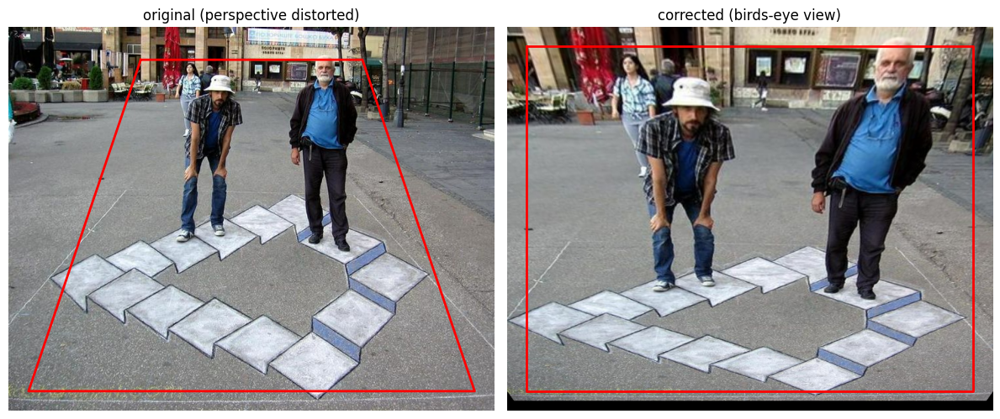

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

chalk_art = cv2.imread("chalk_art.jpg")

if chalk_art is None:
    print("error: chalk_art.jpg not found")
else:
    height, width = chalk_art.shape[:2]

    #source points: 4 corners AS THEY APPEAR in the distorted photo
    #(narrower at the top/far edge, wider at the bottom/near edge)
    src_points = np.float32([
        [200, 50],
        [width - 200, 50],
        [width - 30, height - 30],
        [30, height - 30]
    ])

    #destination points: where these 4 corners SHOULD be for a perfect
    #top-down square/rectangle view
    dst_points = np.float32([
        [30, 30],
        [width - 30, 30],
        [width - 30, height - 30],
        [30, height - 30]
    ])

    print("source points (distorted trapezoid):")
    print(src_points)
    print("\ndestination points (corrected rectangle):")
    print(dst_points)

    M = cv2.getPerspectiveTransform(src_points, dst_points)

    print("\n3x3 perspective transformation Matrix:")
    print(M)

    corrected = cv2.warpPerspective(chalk_art, M, (width, height))

    chalk_art_rgb = cv2.cvtColor(chalk_art, cv2.COLOR_BGR2RGB)
    corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(chalk_art_rgb)
    plt.title("original (perspective distorted)")
    pts_closed = np.vstack([src_points, src_points[0]])
    plt.plot(pts_closed[:, 0], pts_closed[:, 1], 'r-', linewidth=2)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_rgb)
    plt.title("corrected (birds-eye view)")
    pts_closed_dst = np.vstack([dst_points, dst_points[0]])
    plt.plot(pts_closed_dst[:, 0], pts_closed_dst[:, 1], 'r-', linewidth=2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# **task 9**

In [25]:
!wget -q https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching/s1.jpg
!wget -q https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching/s2.jpg

camera 1 view size: 1246x700
camera 2 view size: 1385x700

total matches found: 1084, using top 50

homography matrix (3x3):
[[ 9.99537063e-01  4.22368089e-04  4.29036373e+02]
 [ 9.22452685e-06  1.00055359e+00 -7.81487704e-02]
 [ 9.41569337e-08  7.64031956e-07  1.00000000e+00]]


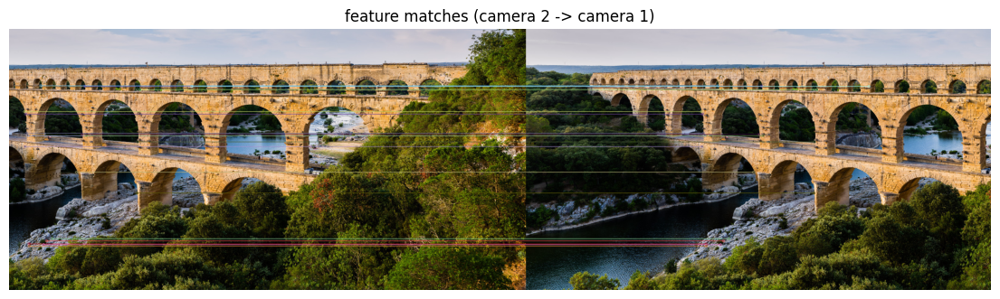

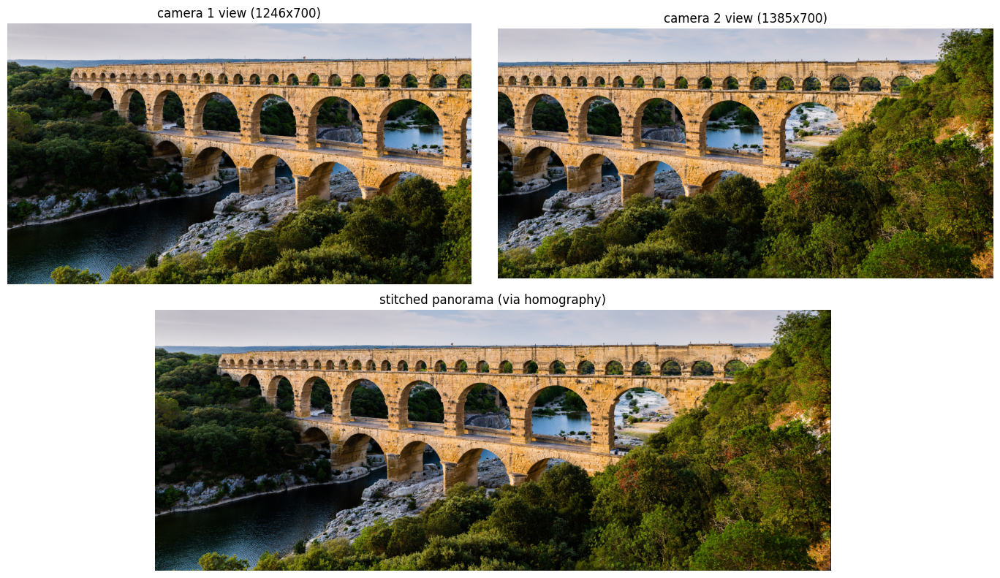

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cam1 = cv2.imread("s1.jpg")
cam2 = cv2.imread("s2.jpg")

if cam1 is None or cam2 is None:
    print("error: one or both panorama images not found")
else:
    h1, w1 = cam1.shape[:2]
    h2, w2 = cam2.shape[:2]

    print(f"camera 1 view size: {w1}x{h1}")
    print(f"camera 2 view size: {w2}x{h2}")

    gray1 = cv2.cvtColor(cam1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(cam2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(2000)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des2, des1)
    matches = sorted(matches, key=lambda x: x.distance)

    good_matches = matches[:50]

    print(f"\ntotal matches found: {len(matches)}, using top {len(good_matches)}")

    src_points_cam2 = np.float32([kp2[m.queryIdx].pt for m in good_matches])
    dst_points_cam1 = np.float32([kp1[m.trainIdx].pt for m in good_matches])

    H, status = cv2.findHomography(src_points_cam2, dst_points_cam1, cv2.RANSAC, 5.0)

    print("\nhomography matrix (3x3):")
    print(H)

    panorama_width = w1 + w2
    panorama_canvas = cv2.warpPerspective(cam2, H, (panorama_width, h1))
    panorama_canvas[:, :w1] = cam1

    cols = np.where(panorama_canvas.max(axis=(0, 2)) > 0)[0]
    panorama_canvas = panorama_canvas[:, :cols[-1] + 1]

    cam1_rgb = cv2.cvtColor(cam1, cv2.COLOR_BGR2RGB)
    cam2_rgb = cv2.cvtColor(cam2, cv2.COLOR_BGR2RGB)
    panorama_rgb = cv2.cvtColor(panorama_canvas, cv2.COLOR_BGR2RGB)

    match_img = cv2.drawMatches(cam2, kp2, cam1, kp1, good_matches[:20], None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    match_img_rgb = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 5))
    plt.imshow(match_img_rgb)
    plt.title("feature matches (camera 2 -> camera 1)")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cam1_rgb)
    plt.title(f"camera 1 view ({w1}x{h1})")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cam2_rgb)
    plt.title(f"camera 2 view ({w2}x{h2})")
    plt.axis("off")

    plt.subplot(2, 1, 2)
    plt.imshow(panorama_rgb)
    plt.title("stitched panorama (via homography)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# **task 10**

frame background size: 2560x2560


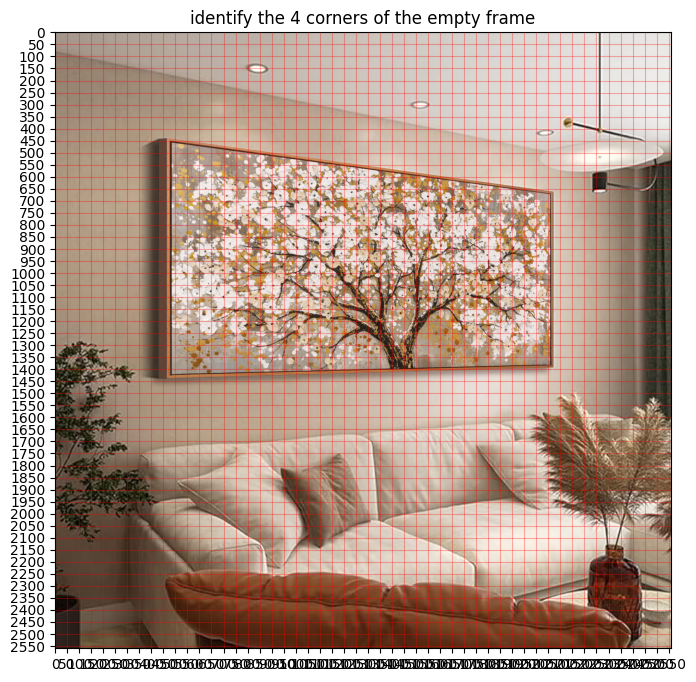

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

painting = cv2.imread("cv_image.jpg")
frame_bg = cv2.imread("painting_frame.jpg")

if painting is None or frame_bg is None:
    print("error: one or both images not found")
else:
    frame_h, frame_w = frame_bg.shape[:2]
    print(f"frame background size: {frame_w}x{frame_h}")

    frame_bg_rgb = cv2.cvtColor(frame_bg, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(frame_bg_rgb)
    plt.xticks(np.arange(0, frame_w, 50))
    plt.yticks(np.arange(0, frame_h, 50))
    plt.grid(True, color='red', alpha=0.3)
    plt.title("identify the 4 corners of the empty frame")
    plt.show()

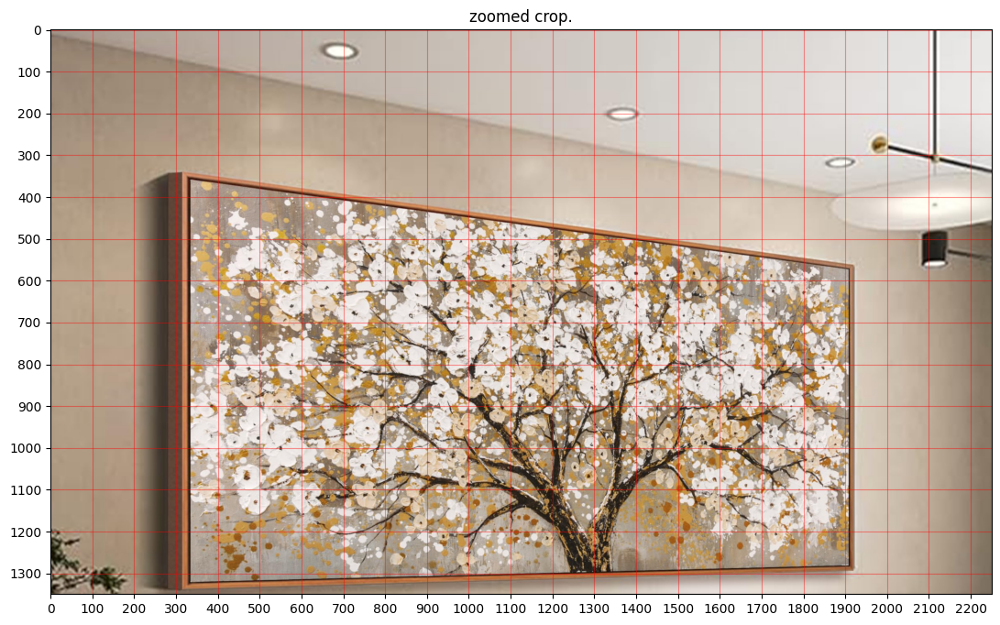

In [28]:
#crop roughly around the frame based on visual proportions, then zoom in
crop = frame_bg[100:1450, 150:2400]
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(crop_rgb)
plt.xticks(np.arange(0, crop.shape[1], 100))
plt.yticks(np.arange(0, crop.shape[0], 100))
plt.grid(True, color='red', alpha=0.4)
plt.title("zoomed crop.")
plt.show()

In [29]:
painting = cv2.imread("cv_image.jpg")
frame_bg = cv2.imread("painting_frame.jpg")

frame_h, frame_w = frame_bg.shape[:2]

#step 1: linear scale
scale_factor = 0.4
painting_h_orig, painting_w_orig = painting.shape[:2]
painting_w = int(painting_w_orig * scale_factor)
painting_h = int(painting_h_orig * scale_factor)

scale_matrix_2x2 = np.array([
    [scale_factor, 0],
    [0, scale_factor]
])
print("Step 1 - linear scale matrix:")
print(scale_matrix_2x2)

painting_scaled = cv2.resize(painting, (painting_w, painting_h))

#step 2: rigid transformation
canvas_w, canvas_h = frame_w, frame_h
blank_canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

tx_rigid, ty_rigid = 50, 50
angle_deg = 5
angle_rad = np.deg2rad(angle_deg)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

rigid_3x3 = np.array([
    [cos_a, -sin_a, tx_rigid],
    [sin_a,  cos_a, ty_rigid],
    [0,      0,     1]
])
print("\nstep 2 - rigid transformation matrix:")
print(rigid_3x3)

M_rigid = rigid_3x3[:2, :].astype(np.float32)
painting_rigid = cv2.warpAffine(painting_scaled, M_rigid, (canvas_w, canvas_h))

mask_rigid = np.any(painting_rigid != 0, axis=2)
blank_canvas[mask_rigid] = painting_rigid[mask_rigid]

Step 1 - linear scale matrix:
[[0.4 0. ]
 [0.  0.4]]

step 2 - rigid transformation matrix:
[[ 0.9961947  -0.08715574 50.        ]
 [ 0.08715574  0.9961947  50.        ]
 [ 0.          0.          1.        ]]


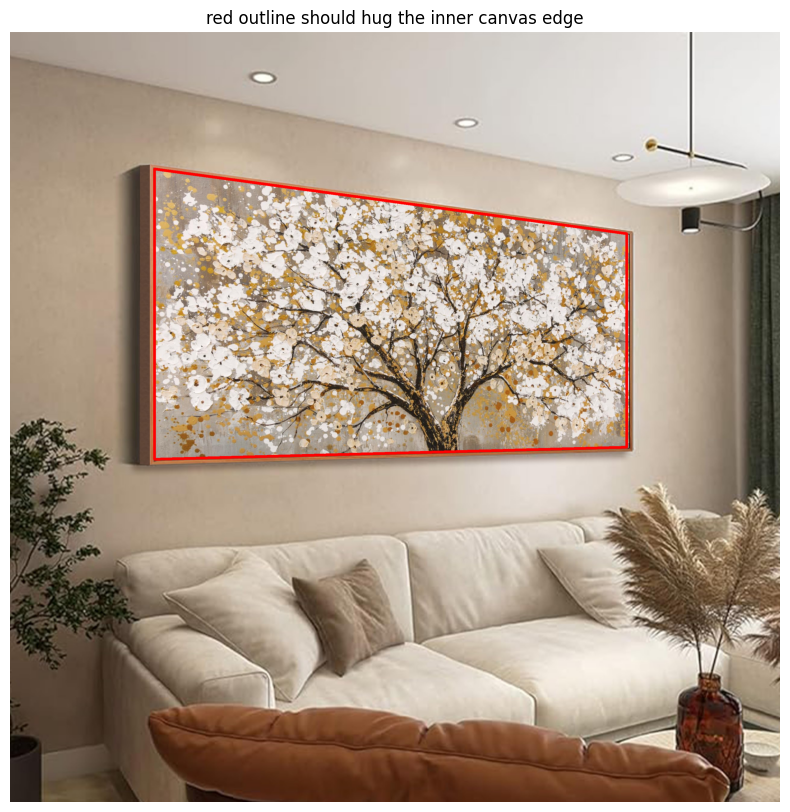

In [30]:
frame_corners = np.float32([
    [480, 455],
    [2050, 670],
    [2050, 1380],
    [480, 1420]
])

check = frame_bg.copy()
cv2.polylines(check, [frame_corners.astype(np.int32)], True, (0, 0, 255), 8)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(check, cv2.COLOR_BGR2RGB))
plt.title("red outline should hug the inner canvas edge")
plt.axis("off")
plt.show()


step 3 - painting's corners after rigid transform (src):
[[ 50.        50.      ]
 [343.87744   75.710945]
 [329.49673  240.08307 ]
 [ 35.6193   214.37213 ]]
frame's angled corners (dst):
[[ 480.  455.]
 [2050.  670.]
 [2050. 1380.]
 [ 480. 1420.]]

step 3 - projective transformation matrix:
[[8.33797544e+00 7.29478263e-01 6.05170841e+01]
 [1.10156003e+00 6.38170045e+00 1.12961653e+02]
 [1.29847234e-03 1.13601380e-04 1.00000000e+00]]


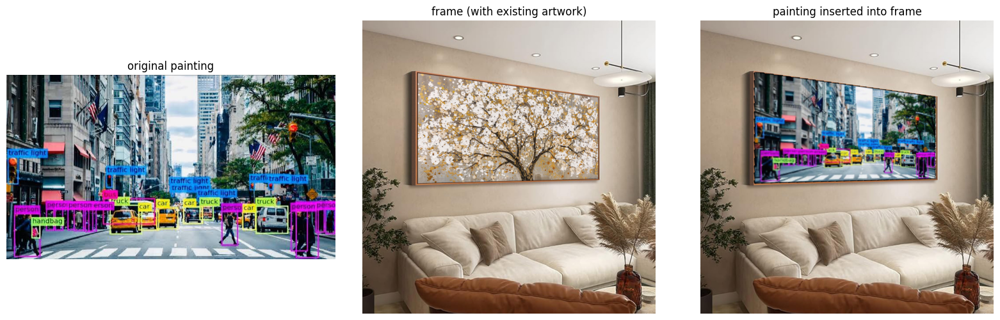

In [31]:
#step 3: projective transformation
corners_orig = np.float32([
    [0, 0],
    [painting_w, 0],
    [painting_w, painting_h],
    [0, painting_h]
]).reshape(-1, 1, 2)

src_corners = cv2.transform(corners_orig, M_rigid).reshape(-1, 2).astype(np.float32)

print("\nstep 3 - painting's corners after rigid transform (src):")
print(src_corners)
print("frame's angled corners (dst):")
print(frame_corners)

M_projective = cv2.getPerspectiveTransform(src_corners, frame_corners)
print("\nstep 3 - projective transformation matrix:")
print(M_projective)

painting_warped = cv2.warpPerspective(blank_canvas, M_projective, (canvas_w, canvas_h))

mask_final = np.any(painting_warped != 0, axis=2)
result = frame_bg.copy()
result[mask_final] = painting_warped[mask_final]

painting_rgb = cv2.cvtColor(painting, cv2.COLOR_BGR2RGB)
frame_bg_rgb = cv2.cvtColor(frame_bg, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(painting_rgb)
plt.title("original painting")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(frame_bg_rgb)
plt.title("frame (with existing artwork)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("painting inserted into frame")
plt.axis("off")

plt.tight_layout()
plt.show()